## seq_len和batch_size对decode时延的影响

In [17]:
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt
import pandas as pd
from ast import literal_eval
import statistics



Fitting results: [3.60409044e-02 4.35748271e+01]
RMSE: 0.5934


/tmp/ipykernel_5624/553210637.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend()


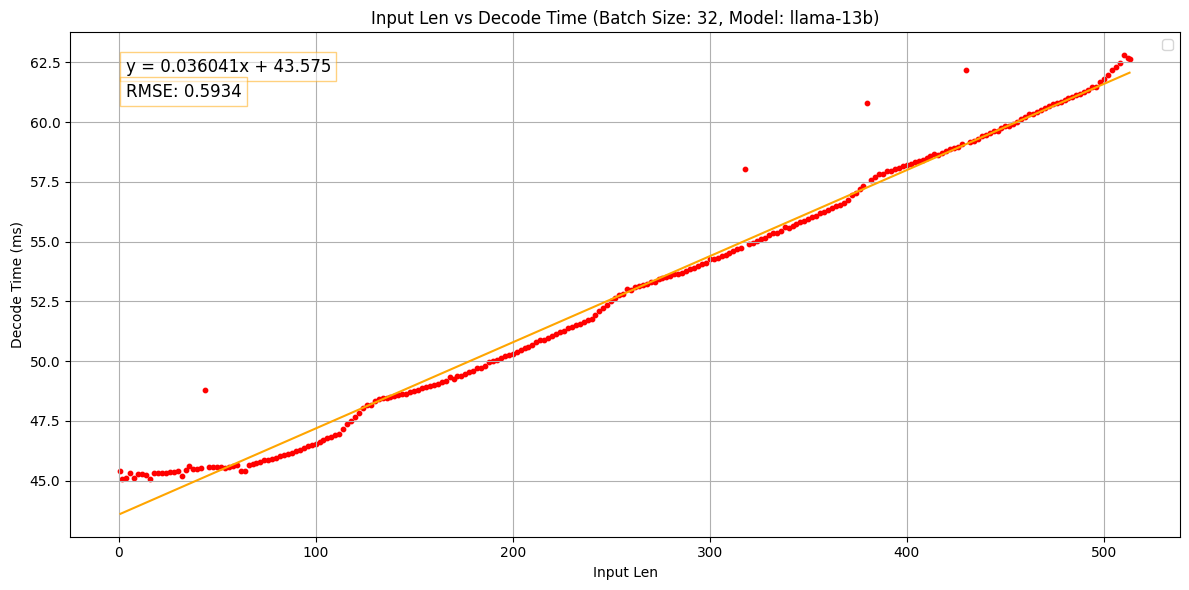

Fitting results: [2.32005019e-02 2.49210137e+01]
RMSE: 0.5517


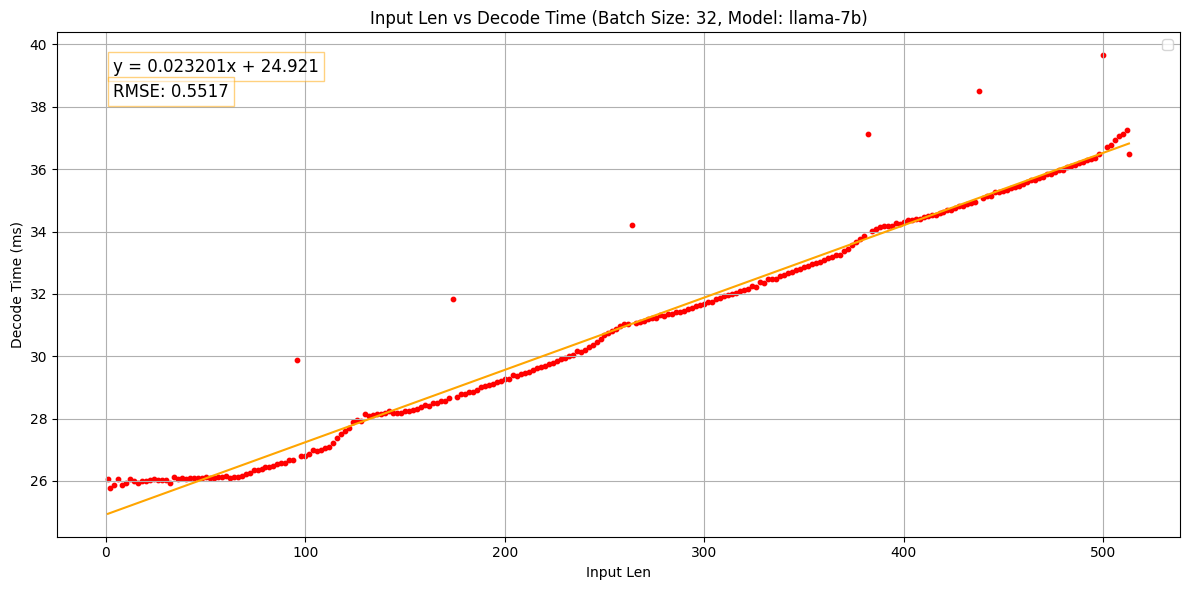

Fitting results: [ 0.30450094 36.35502285]
RMSE: 4.2085


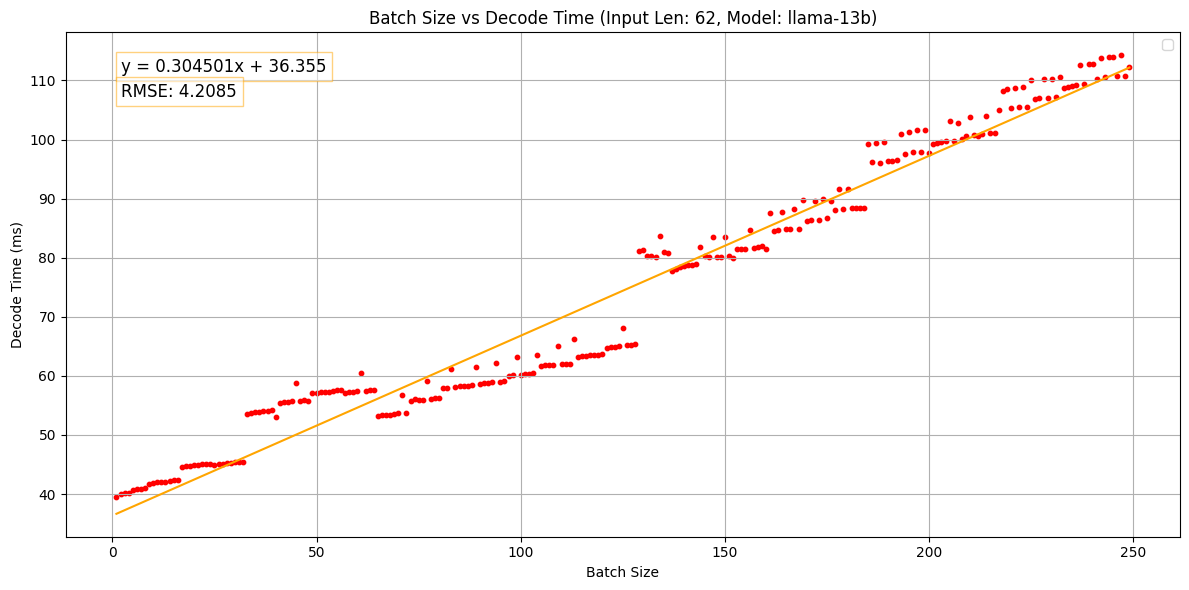

Fitting results: [ 0.21968465 18.64532328]
RMSE: 2.5925


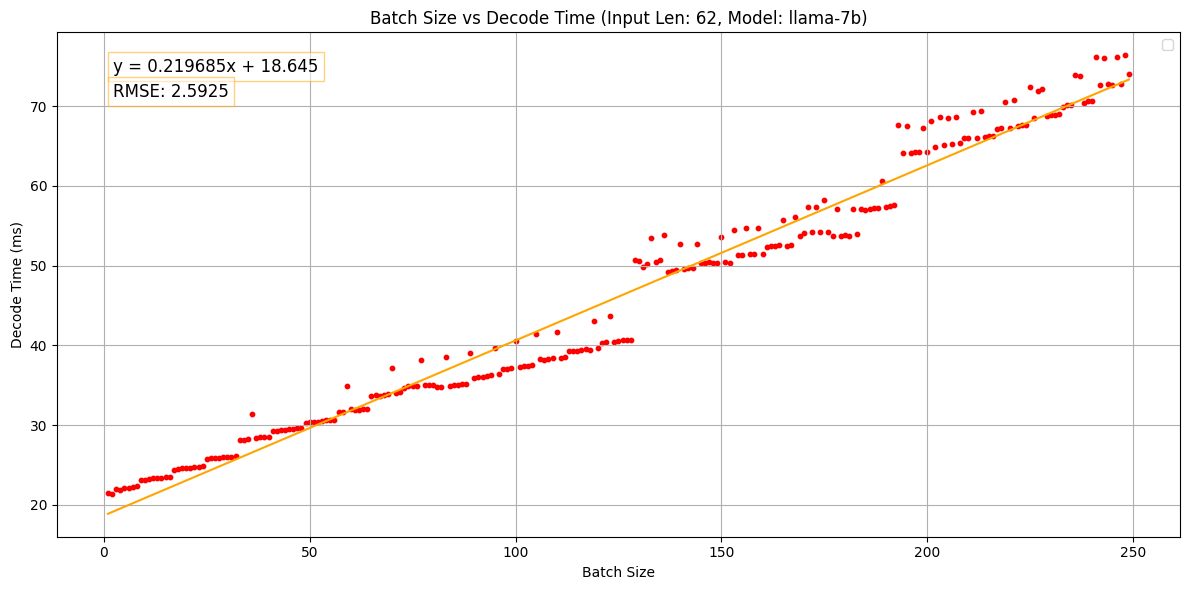

In [2]:

# 拟合token_num和avg_step_time的关系
def fit_data(x, y):

    if len(x) < 2:
        print(f"Not enough data to fit.")
        return None
    
    # 使用numpy的polyfit进行线性拟合
    coefficients = np.polyfit(x, y, 1)

    fit_results = coefficients
    return fit_results

# 绘制token_num和avg_step_time的关系图,使用matplotlib,
def plot_data(x,y,x_label='Input Len', y_label='Decode Time (ms)', title='Input Len vs Decode Time (Batch Size: 32)'):
    # 分配两个子图
    fig, axs = plt.subplots(1, 1, figsize=(12, 6))

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    # 剔除异常值
    # if len(x) > 20:
    #     # 基于IQR方法剔除异常值
    #     q1 = np.percentile(y, 25)
    #     q3 = np.percentile(y, 75)
    #     iqr = q3 - q1
    #     lower_bound = q1 - 1.5 * iqr
    #     upper_bound = q3 + 1.5 * iqr
    #     print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    #     mask = (y >= lower_bound) & (y <= upper_bound)
    #     x = x[mask]
    #     y = y[mask]
    axs.scatter(x, y, color='red', s=10)
    # 拟合曲线
    fit_results = fit_data(x, y)
    if fit_results is not None:
        print(f'Fitting results: {fit_results}')
        fit_line = np.polyval(fit_results, x)
        axs.plot(x, fit_line, color='orange')
        # 在图片上显示拟合结果
        if len(fit_results) == 2:
            fit_eq = f'y = {fit_results[0]:.6f}x + {fit_results[1]:.3f}'
        elif len(fit_results) == 3:
            fit_eq = f'y = {fit_results[0]:.6f}x^2 + {fit_results[1]:.3f}x + {fit_results[2]:.2f}'
        axs.text(0.05, 0.95, fit_eq, transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
        # 计算拟合的均方根误差
        rmse = np.sqrt(np.mean((y - fit_line) ** 2))
        print(f"RMSE: {rmse:.4f}")
        axs.text(0.05, 0.90, f'RMSE: {rmse:.4f}', transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
    axs.set_title(title)
    axs.set_xlabel(x_label)
    axs.set_ylabel(y_label)
    axs.legend()
    axs.grid(True)
    plt.tight_layout()
    # plt.savefig(f'token_num_vs_avg_step_time.png')
    plt.show()
    
# x = [1,2,4,8,16,32,64,128,256,512]
# y = [45.38995028,45.07872462,45.1242427,45.1165388,45.0797677,45.20393908,45.41728397,48.17039768,52.81580985,62.68493831]
# x = x[6:]
# y = y[6:]

file_path = '/workspace/llm-serve/profiler_test/logs/A6000-t2-test-profile-cuda-graph/data/instance.csv'
instance_df = pd.read_csv(file_path)
instance_df['decode_time'] = instance_df['mean_decode_time'] / instance_df['output_len'] * 1000  # 转换为毫秒


batch_size = 32
model = 'llama-13b'
# 过滤数据
instance_df1 = instance_df[(instance_df['batch_size'] == batch_size) & (instance_df['model'] == model)]
x = instance_df1['input_len'].tolist()
y = instance_df1['decode_time'].tolist()
plot_data(x, y, 'Input Len', 'Decode Time (ms)', f'Input Len vs Decode Time (Batch Size: {batch_size}, Model: {model})')

batch_size = 32
model = 'llama-7b'
# 过滤数据
instance_df1 = instance_df[(instance_df['batch_size'] == batch_size) & (instance_df['model'] == model)]
x = instance_df1['input_len'].tolist()
y = instance_df1['decode_time'].tolist()
plot_data(x, y, 'Input Len', 'Decode Time (ms)', f'Input Len vs Decode Time (Batch Size: {batch_size}, Model: {model})')

input_len = 62
model = 'llama-13b'
# 过滤数据
instance_df2 = instance_df[(instance_df['input_len'] == input_len) & (instance_df['model'] == model)]
x = instance_df2['batch_size'].tolist()
y = instance_df2['decode_time'].tolist()
plot_data(x, y, 'Batch Size', 'Decode Time (ms)', f'Batch Size vs Decode Time (Input Len: {input_len}, Model: {model})')

input_len = 62
model = 'llama-7b'
# 过滤数据
instance_df2 = instance_df[(instance_df['input_len'] == input_len) & (instance_df['model'] == model)]
x = instance_df2['batch_size'].tolist()
y = instance_df2['decode_time'].tolist()
plot_data(x, y, 'Batch Size', 'Decode Time (ms)', f'Batch Size vs Decode Time (Input Len: {input_len}, Model: {model})')

### 开题画图

Fitting results: [3.60409044e-02 4.35748271e+01]
RMSE: 0.5934
Fitting results: [ 0.30450094 36.35502285]
RMSE: 4.2085


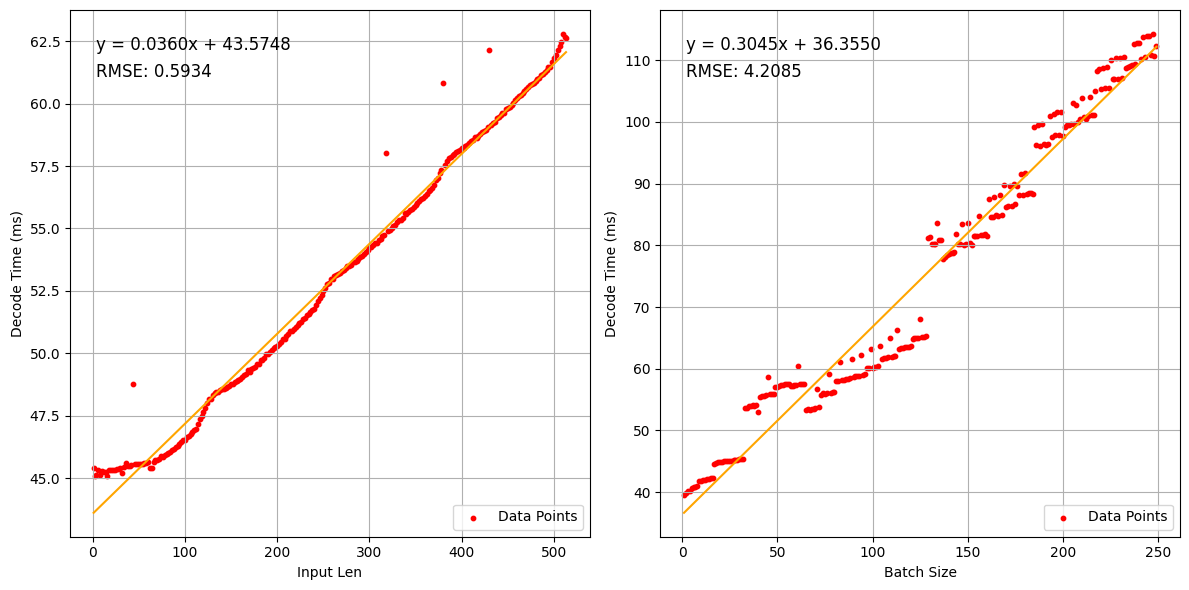

In [10]:

# 拟合token_num和avg_step_time的关系
def fit_data(x, y):

    if len(x) < 2:
        print(f"Not enough data to fit.")
        return None
    
    # 使用numpy的polyfit进行线性拟合
    coefficients = np.polyfit(x, y, 1)

    fit_results = coefficients
    return fit_results

# 绘制token_num和avg_step_time的关系图,使用matplotlib,
def plot_data(x,y,x_label='Input Len', y_label='Decode Time (ms)', title='Input Len vs Decode Time (Batch Size: 32)', axs=None):

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    # 剔除异常值
    # if len(x) > 20:
    #     # 基于IQR方法剔除异常值
    #     q1 = np.percentile(y, 25)
    #     q3 = np.percentile(y, 75)
    #     iqr = q3 - q1
    #     lower_bound = q1 - 1.5 * iqr
    #     upper_bound = q3 + 1.5 * iqr
    #     print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    #     mask = (y >= lower_bound) & (y <= upper_bound)
    #     x = x[mask]
    #     y = y[mask]
    axs.scatter(x, y, color='red', label='Data Points', s=10)
    # 拟合曲线
    fit_results = fit_data(x, y)
    if fit_results is not None:
        print(f'Fitting results: {fit_results}')
        fit_line = np.polyval(fit_results, x)
        axs.plot(x, fit_line, color='orange')
        # 在图片上显示拟合结果
        # fit_eq = f'y = {fit_results[0]:.6f}x^2 + {fit_results[1]:.3f}x + {fit_results[2]:.2f}'
        fit_eq = f'y = {fit_results[0]:.4f}x + {fit_results[1]:.4f}'
        axs.text(0.05, 0.95, fit_eq, transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', )
        # 计算拟合的均方根误差
        rmse = np.sqrt(np.mean((y - fit_line) ** 2))
        print(f"RMSE: {rmse:.4f}")
        axs.text(0.05, 0.90, f'RMSE: {rmse:.4f}', transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', )
    axs.set_title(title)
    axs.set_xlabel(x_label)
    axs.set_ylabel(y_label)
    axs.legend()
    axs.grid(True)

    
# x = [1,2,4,8,16,32,64,128,256,512]
# y = [45.38995028,45.07872462,45.1242427,45.1165388,45.0797677,45.20393908,45.41728397,48.17039768,52.81580985,62.68493831]
# x = x[6:]
# y = y[6:]

file_path = '/workspace/llm-serve/profiler_test/logs/A6000-t2-test-profile-cuda-graph/data/instance.csv'
instance_df = pd.read_csv(file_path)
instance_df['decode_time'] = instance_df['mean_decode_time'] / instance_df['output_len'] * 1000  # 转换为毫秒

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

batch_size = 32
model = 'llama-13b'
# 过滤数据
instance_df1 = instance_df[(instance_df['batch_size'] == batch_size) & (instance_df['model'] == model)]
x = instance_df1['input_len'].tolist()
y = instance_df1['decode_time'].tolist()
# plot_data(x, y, 'Input Len', 'Decode Time (ms)', f'Input Len vs Decode Time (Batch Size: {batch_size}, Model: {model})',axs[0])
plot_data(x, y, 'Input Len', 'Decode Time (ms)', f'',axs[0])


input_len = 62
model = 'llama-13b'
# 过滤数据
instance_df2 = instance_df[(instance_df['input_len'] == input_len) & (instance_df['model'] == model)]
x = instance_df2['batch_size'].tolist()
y = instance_df2['decode_time'].tolist()
# plot_data(x, y, 'Batch Size', 'Decode Time (ms)', f'Batch Size vs Decode Time (Input Len: {input_len}, Model: {model})',axs[1])
plot_data(x, y, 'Batch Size', 'Decode Time (ms)', f'',axs[1])

plt.tight_layout()
plt.savefig(f'topic_proposal_decode_input_len_and_bs_vs_avg_step_time.png')
plt.show()

## 统计每秒到来的请求数和完成的请求数

In [1]:
from ast import literal_eval
import pandas as pd
import numpy as np
import warnings
import os

# 忽略 openpyxl 的这个特定警告
warnings.filterwarnings("ignore", message="Title is more than 31 characters")

def cal_avg_rate(res):
    """
    计算平均速率
    :param res: 包含new_req和finished_req的字典
    :return: 返回平均速率
    """
    if not res['new_req'] or not res['finished_req']:
        return 0, 0
    # 获取第一个和最后一个value非0的时间戳，并进行截取
    new_req_values = list(res['new_req'].values())
    finished_req_values = list(res['finished_req'].values())
    if not new_req_values or not finished_req_values:
        return 0, 0
    first_new_req = next((k for k, v in res['new_req'].items() if v > 0), None)
    last_new_req = next((k for k, v in reversed(res['new_req'].items()) if v > 0), None)
    first_finished_req = next((k for k, v in res['finished_req'].items() if v > 0), None)
    last_finished_req = next((k for k, v in reversed(res['finished_req'].items()) if v > 0), None)
    if first_new_req is None or last_new_req is None or first_finished_req is None or last_finished_req is None:
        return 0, 0
    # print(f"First New Req: {first_new_req}, Last New Req: {last_new_req}")
    # print(f"First Finished Req: {first_finished_req}, Last Finished Req: {last_finished_req}")
    # 计算平均速率
    new_req_rate = sum(new_req_values) / (last_new_req - first_new_req + 1) if (last_new_req - first_new_req + 1) > 0 else 0
    finished_req_rate = sum(finished_req_values) / (last_finished_req - first_finished_req + 1) if (last_finished_req - first_finished_req + 1) > 0 else 0
    return new_req_rate, finished_req_rate

def get_rate(instance_log, start_idx):
    # 获取第一行的timestamp, 向下取整
    tmp_timestamp = instance_log['timestamp'].iloc[start_idx]
    tmp_timestamp = int(tmp_timestamp)
    count = 1
    res = {
        'new_req':{},
        'finished_req':{},
    }
    # 遍历每一行
    for index, row in instance_log.iterrows():
        # 将字符串转换为字典
        try:
            count_change = False
            while row['timestamp'] > tmp_timestamp + count:
                # if not count_change:
                #     if res['new_req'][count] > 0 or res['finished_req'][count] > 0:
                #         # 输出当前秒的new_req之和
                #         print(f"Timestamp: {tmp_timestamp + count - 1}, New Req Sum: {res['new_req'][count]}")
                #         print(f"Timestamp: {tmp_timestamp + count - 1}, Finished Req Sum: {res['finished_req'][count]}")
                count += 1
                count_change = True
            else:
                if count not in res['new_req']:
                    res['new_req'][count] = 0
                res['new_req'][count] += row['new_req'] if not pd.isna(row['new_req']) else 0
                if count not in res['finished_req']:
                    res['finished_req'][count] = 0
                res['finished_req'][count] += row['finished_req'] if not pd.isna(row['finished_req']) else 0
                
                # tmp_timestamp = row['timestamp']
        except (ValueError, SyntaxError):
            print(f"Error parsing dispatch_load_metric at index {index}: {row['dispatch_load_metric']}")
            continue
    # 计算均值
    print(f"Count:{count}, Mean New Req: {np.mean(list(res['new_req'].values()))}, Sum: {sum(res['new_req'].values())}")
    print(f"Count:{count}, Mean Finished Req: {np.mean(list(res['finished_req'].values()))}, Sum: {sum(res['finished_req'].values())}")
    rate = cal_avg_rate(res)
    print(f"avg_new_req_rate: {rate[0]}, avg_finished_req_rate: {rate[1]}")

def get_inference_type(group):
    for i, inference_type in enumerate(group['inference_type']):
        if not pd.isna(inference_type) and inference_type != None:
            return inference_type, i

# 获取instance.csv中每条记录的new_req_num和finished_req_num
def get_new_req_and_finished_req(group):
    seq_lens_prev = []
    bs_prev = 0
    
    # 新建列
    group['new_req'] = 0
    group['finished_req'] = 0
    group['new_bs'] = 0
    for index, row in group.iterrows():
        if row['inference_type'] == 'prefill':
            continue
        seq_lens = literal_eval(row['seq_lens']) if pd.notnull(row['seq_lens']) else []
        cur_p, pre_p, count = 0, 0, 0
        while True:
            if cur_p >= len(seq_lens) or pre_p >= len(seq_lens_prev):
                new_req_num = len(seq_lens) - count
                finished_req_num = len(seq_lens_prev) - count
                bs = bs_prev + new_req_num - finished_req_num

                if bs != row['bs']:
                    print(f"New req num: {new_req_num}, Finished req num: {finished_req_num}, Batch size: {bs}, \nSeq lens prev: {seq_lens_prev}, \nSeq lens: {seq_lens}")

                group.at[index, 'new_req'] = new_req_num
                group.at[index, 'finished_req'] = finished_req_num
                group.at[index, 'new_bs'] = bs

                seq_lens_prev = seq_lens
                bs_prev = bs
                break
            if 0 <= seq_lens[cur_p] - seq_lens_prev[pre_p] and seq_lens[cur_p] - seq_lens_prev[pre_p] < 14:
                cur_p += 1
                pre_p += 1
                count += 1
            else:
                pre_p += 1
    # return group


def get_profiling_data(filename,):
    if os.path.exists(filename.replace('.csv', '_metrics.xlsx')) is False:
        instance_log = pd.read_csv(filename)
        # 删除dispatch_load_metric为-inf的行
        instance_log = instance_log[instance_log['dispatch_load_metric'] != -np.inf]

        # 将profiling_data列(inference_type,num_seqs,running_seq_lens,last_inference_latency)中的内容转化为4列
        instance_log[['profiling_inference_type', 'profiling_num_seqs', 'running_seq_lens', 'last_inference_latency']] = (
            instance_log['profiling_data']
            .apply(lambda x: literal_eval(x) if pd.notnull(x) else ("", None, None, None))
            .apply(pd.Series)
        )
        # 根据seq_lens列中的字符串转换为列表，得到最大序列长度
        instance_log['max_seq_len'] = instance_log['seq_lens'].apply(lambda x: max(literal_eval(x)) if pd.notnull(x) and len(literal_eval(x))>0 else 0)

        instance_log_group = instance_log.groupby("instance_id")
        # 一个group保存为一个sheet
        with pd.ExcelWriter(filename.replace('.csv', '_metrics.xlsx')) as writer:
            for i, (instance_id, group) in enumerate(instance_log_group):
                
                inference_type, start_idx = get_inference_type(group)
                if inference_type == 'decode':
                    get_new_req_and_finished_req(group)
                    get_rate(group,start_idx)
                group.to_excel(writer, sheet_name=f'Instance_{instance_id}', index=False)
    else:
        filename = filename.replace('.csv', '_metrics.xlsx')
        instance_log = pd.read_excel(filename, sheet_name=None)
        for instance_id, group in instance_log.items():
            inference_type, start_idx = get_inference_type(group)
            if inference_type == 'decode':  
                # 如果已经有new_req和finished_req列，则不需要重新计算
                if 'new_req' not in group.columns or 'finished_req' not in group.columns:
                    get_new_req_and_finished_req(group)
                get_rate(group,start_idx)
            else:
                print(f"Instance {instance_id} is not decode type, skipping...")
    print()

# get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-t2-pdd-4/llama-7b/poisson/serve_4_tp1_1000_qps_6_instance.csv')
# get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1-128-256/llama-7b/poisson/serve_pdd_2000_qps_4_1,1_1,1_instance.csv')
# get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1-128-256/llama-7b/poisson/serve_pdd_2000_qps_4_1_1,1,1_instance.csv')
# get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1-128-256/llama-7b/poisson/serve_pdd_2000_qps_4_1,1_2_instance.csv')
# get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson/serve_pdd_tp1_2000_qps_4_1_3_instance.csv')
# get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson/serve_pdd_tp1_2000_qps_4_2_2_instance.csv')
# get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson/serve_pdd_tp1_2000_qps_4_3_1_instance.csv')
get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson/benchmark_pdd_2000_qps-4_1-2_instance.csv')

Count:664, Mean New Req: 3.0271084337349397, Sum: 2010
Count:664, Mean Finished Req: 3.0271084337349397, Sum: 2010
avg_new_req_rate: 3.459552495697074, avg_finished_req_rate: 3.0316742081447963
Instance Instance_a9deb6e57bee43249c924997e1cd79e8 is not decode type, skipping...



In [ ]:

filename='serve_pdd_2000_qps_4_1,1_1,1_instance_metrics.csv'
# /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1-128-256/llama-7b/poisson/serve_pdd_2000_qps_4_1,1_1,1_instance_metrics.xlsx
instance_log = pd.read_csv(filename)
# 删除dispatch_load_metric为-inf的行
instance_log = instance_log[instance_log['dispatch_load_metric'] != -np.inf]
get_rate(instance_log, 4)


## qps与batchsize的关系

{'prefill': [1.0144927536231885, 1.0435967302452316], 'decode': [74.59741681260945, 72.49580655701993]}
{'prefill': [1.0231660231660231, 1.0189274447949528], 'decode': [85.30377336031425, 85.01580343753605]}
{'decode': [89.81410545290672, 91.60332749562171], 'prefill': [1.065934065934066, 1.0405405405405406]}
{'prefill': [1.052325581395349, 1.05], 'decode': [91.40437407449596, 93.14998900373872]}
{'prefill': [1.0284697508896796, 1.0651629072681705], 'decode': [92.7920472265538, 91.67085029398463]}
{'decode': [94.83557046979865, 94.58853588091536], 'prefill': [1.038327526132404, 1.0247524752475248]}
{'prefill': [1.241046831955923], 'decode': [92.77839592025963, 94.49311610830657]}
{'decode': [104.1079383886256, 104.58680082864753], 'prefill': [1.584097859327217, 1.6246418338108883]}
{'prefill': [1.6715116279069768, 1.5124223602484472], 'decode': [105.23683267646005, 103.90251910219675]}
{'prefill': [1.121372031662269, 1.0588235294117647], 'decode': [94.42053429929817, 98.78057760902082]

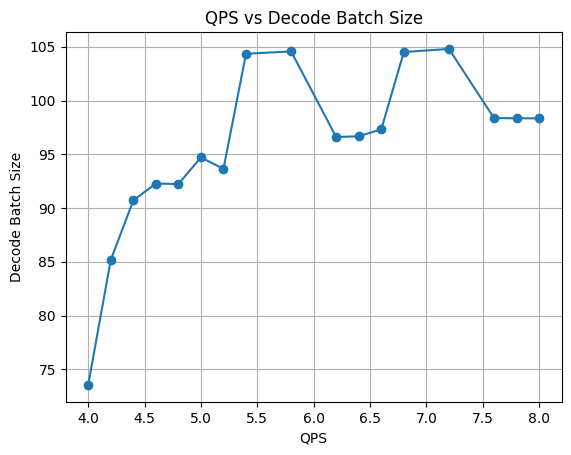

In [18]:
def get_inference_type(group):
    for inference_type in group['inference_type']:
        if not pd.isna(inference_type) and inference_type != None:
            return inference_type
        
def get_profiling_data(filename,):
    enable_pd = True if 'pdd' in filename else False
    instance_log = pd.read_csv(filename)
    # 删除dispatch_load_metric为-inf的行
    instance_log = instance_log[instance_log['dispatch_load_metric'] != -np.inf]

    # 将profiling_data列(inference_type,num_seqs,running_seq_lens,last_inference_latency)中的内容转化为4列
    instance_log[['profiling_inference_type', 'profiling_num_seqs', 'running_seq_lens', 'last_inference_latency']] = (
        instance_log['profiling_data']
        .apply(lambda x: literal_eval(x) if pd.notnull(x) else ("", None, None, None))
        .apply(pd.Series)
    )
    instance_log_group = instance_log.groupby("instance_id")
    res = {} if enable_pd else []

    for i, (instance_id, group) in enumerate(instance_log_group):
        if enable_pd:
            infertence_type = get_inference_type(group)
            if infertence_type not in res:
                res[infertence_type] = []
            res[infertence_type].append(group["profiling_num_seqs"].mean())
        else:
            res.append(group["profiling_num_seqs"].mean())
    return res
decode_bs = []
qps = [10, 10.2, 10.4, 10.6, 10.8, 11, 11.2, 11.4, 11.6, 11.8, 12, 12.2, 12.4, 12.6, 12.8, 13, 13.2, 13.4, 13.8, 14]
qps = [4, 4.2, 4.4, 4.6, 4.8, 5, 5.2, 5.4, 5.8, 6.2, 6.4, 6.6, 6.8, 7.2, 7.6, 7.8, 8]   # 5.6, 6, 7, 7.4,
for q in qps:
    filename = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1-128-256/llama-7b/poisson/serve_pdd_2000_qps_{q}_1,1_1,1_instance.csv'
    filename = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson/serve_pdd_2000_qps_{q}_1,1_1,1_instance.csv'
    res = get_profiling_data(filename)
    print(res)
    decode_bs.append(mean(res['decode']) if 'decode' in res else 0)
print(decode_bs)
plt.plot(qps, decode_bs, marker='o')
plt.xlabel('QPS')
plt.ylabel('Decode Batch Size')
plt.title('QPS vs Decode Batch Size')
plt.grid(True)
plt.show()

Instance Instance_0783f024ec064092bdabf3233668cd34 inference type: decode
BS: mean=190.065625, median=225.0 max=287, min=1, sum=1763809


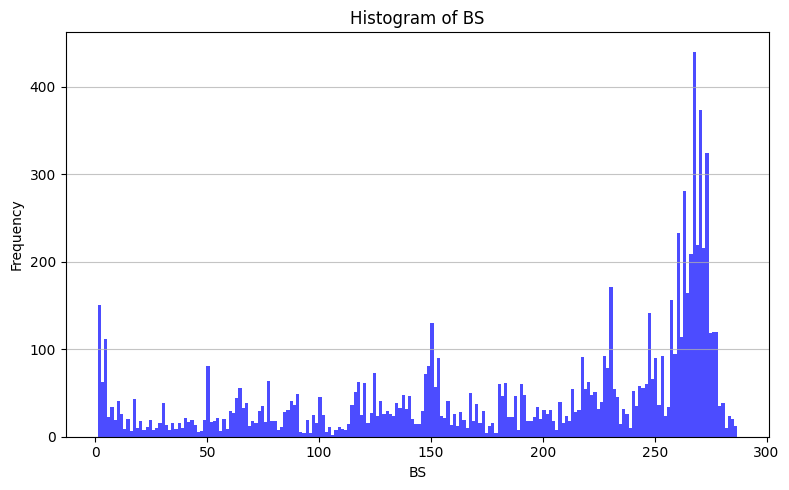

Instance Instance_a9deb6e57bee43249c924997e1cd79e8 inference type: prefill


In [18]:
def get_inference_type(group):
    for i, inference_type in enumerate(group['profiling_inference_type']):
        if not pd.isna(inference_type) and inference_type != None:
            return inference_type
instance_log = pd.read_excel('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson/benchmark_pdd_2000_qps-4_1-2_instance_metrics.xlsx',  sheet_name=None)
for instance_id, group in instance_log.items():
    inference_type = get_inference_type(group)
    print(f"Instance {instance_id} inference type: {inference_type}")
    if inference_type == 'decode':  
        
        x1 = group['profiling_num_seqs'].tolist()
        # 去掉nan
        x1 = [x for x in x1 if pd.notna(x)]
        x1 = [int(x) for x in x1]
        print(f"BS: mean={mean(x1)}, median={statistics.median(x1)} max={max(x1)}, min={min(x1)}, sum={sum(x1)}")
        # 绘制x1直方图
        plt.figure(figsize=(8, 5))
        plt.hist(x1, bins=200, color='blue', alpha=0.7)
        plt.xlabel('BS')
        plt.ylabel('Frequency')
        plt.title('Histogram of BS')
        plt.grid(axis='y', alpha=0.75)
        plt.tight_layout()
        plt.show()

[182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381,

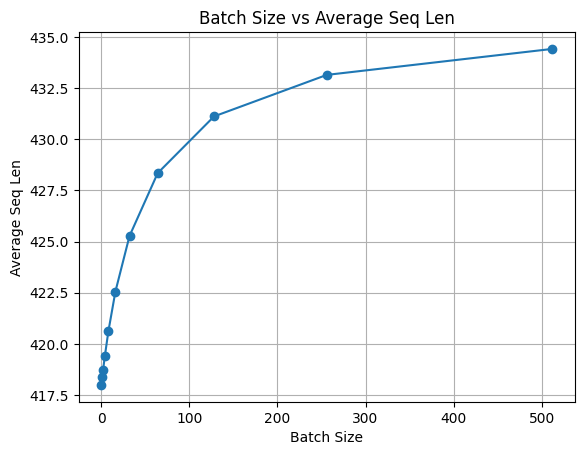

In [16]:
def get_seq_len(b, other_overhead=18.343315250706105):
    args = [0.23448891980846398, 0.00037640856293522356, 18.343315250706105]
    input_len, output_len = 182, 473
    l = [input_len + i for i in range(output_len)]
    t = [args[0] * b + args[1] * b * ll + other_overhead for ll in l]
    l_mul_t = [l[i] * t[i] for i in range(len(l))]
    print(l)
    print(t)
    print()
    return sum(l_mul_t) / sum(t)
bs = [0,1,2,4,8,16,32,64,128,256,512]
res = [get_seq_len(b) for b in bs]
print(res)
plt.plot(bs, res, marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Average Seq Len')
plt.title('Batch Size vs Average Seq Len')
plt.grid(True)
plt.show()